In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

# parameters
J = 1.0  # scaling factor
dt = 0.01  # time step
T = 100  # total time
time_steps = int(T / dt)

def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_method(r, A, dt, J):
    inputs = np.dot(A, r)
    return r + dt * (-r + sigmoid(inputs))

def compute_mean_firing_rate(rates):
    return np.mean(rates, axis=1)

def compute_variance_firing_rate(rates):
    return np.var(rates, axis=1)

def process_dataset(folder_path):
    graphml_files = [f for f in os.listdir(folder_path) if f.endswith('.graphml')]
    graphs = []
    for file in graphml_files:
        file_path = os.path.join(folder_path, file)
        graph = nx.read_graphml(file_path)
        graphs.append(graph)

    N = len(graphs[0].nodes)

    # create weighted adjacency matrices and scale them by J
    matrices = []
    for graph in graphs:
        adj_matrix = nx.adjacency_matrix(graph, weight="d11").todense()
        avg_fibers = np.mean(adj_matrix[adj_matrix > 0])  # normalise by average fibers
        scaled_adj_matrix = J * adj_matrix / avg_fibers  # scale and normalise
        matrices.append(scaled_adj_matrix)

    average_matrix = np.mean(matrices, axis=0)

    initial_rates = np.random.uniform(0, 1, N)
    rates_data_network = np.zeros((time_steps, N))
    r = initial_rates.copy()
    for t in range(time_steps):
        rates_data_network[t] = r
        r = euler_method(r, average_matrix, dt, J)

    mean_firing_rate_data_network = compute_mean_firing_rate(rates_data_network)
    variance_firing_rate_data_network = compute_variance_firing_rate(rates_data_network)

    # plotting
    plt.figure(figsize=(10, 6))
    for i in range(min(5, rates_data_network.shape[1])):  
        plt.plot(rates_data_network[:, i], label=f'Neuron {i}')
    plt.title(f'Individual Trajectories ({N} nodes network)')
    plt.xlabel('Time Steps')
    plt.ylabel('Firing Rate')
    plt.legend()
    plt.xlim(0, 2000)  
    plt.xticks(np.arange(0, 2001, 500))
    plt.show()

    plt.plot(mean_firing_rate_data_network, label=f'{N} nodes network')
    plt.title('Mean Firing Rate')
    plt.xlabel('Time')
    plt.ylabel('Mean Firing Rate')
    plt.xlim(0, 2000)
    plt.xticks(np.arange(0, 2001, 500))
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(variance_firing_rate_data_network, label=f'{N} nodes network')
    plt.title('Variance of Firing Rate')
    plt.xlabel('Time')
    plt.ylabel('Variance')
    plt.xlim(0, 2000)
    plt.xticks(np.arange(0, 2001, 500))
    plt.legend()
    plt.show()

In [ ]:
folder_path_83 = '...'
folder_path_129 = '...'
folder_path_234 = '...'
folder_path_463 = '...'
folder_path_1015 = '...'
averaged_1015 = '...'

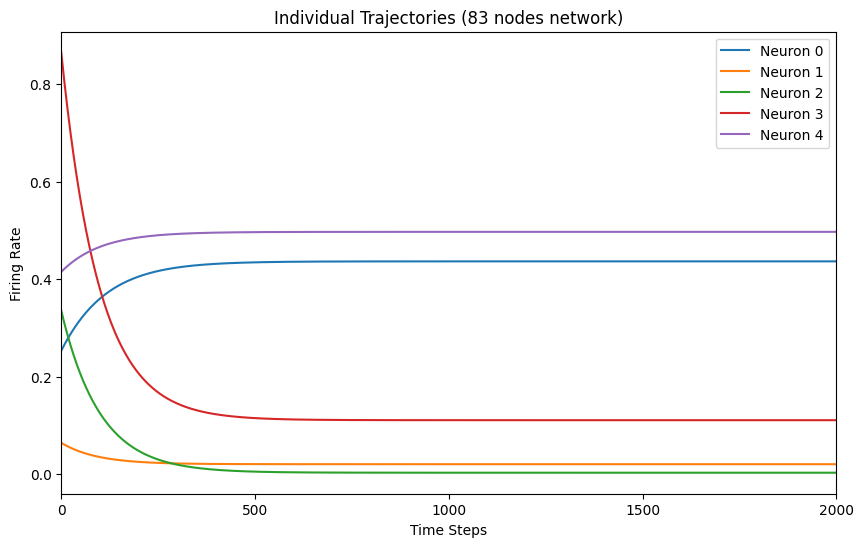

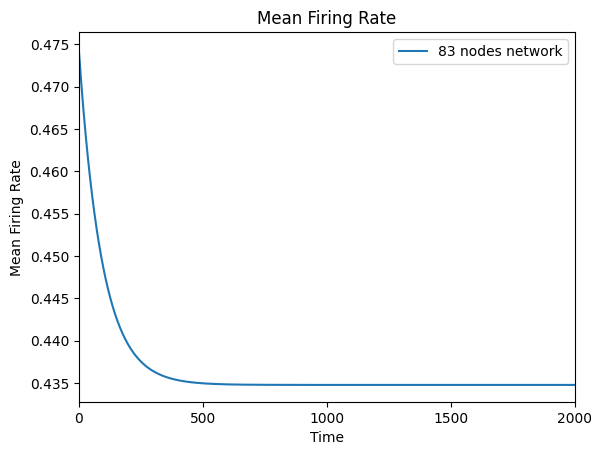

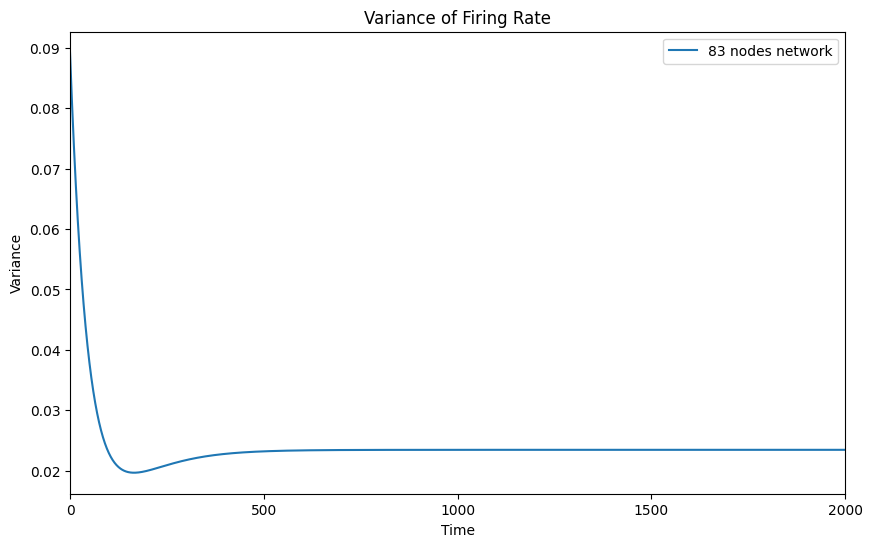

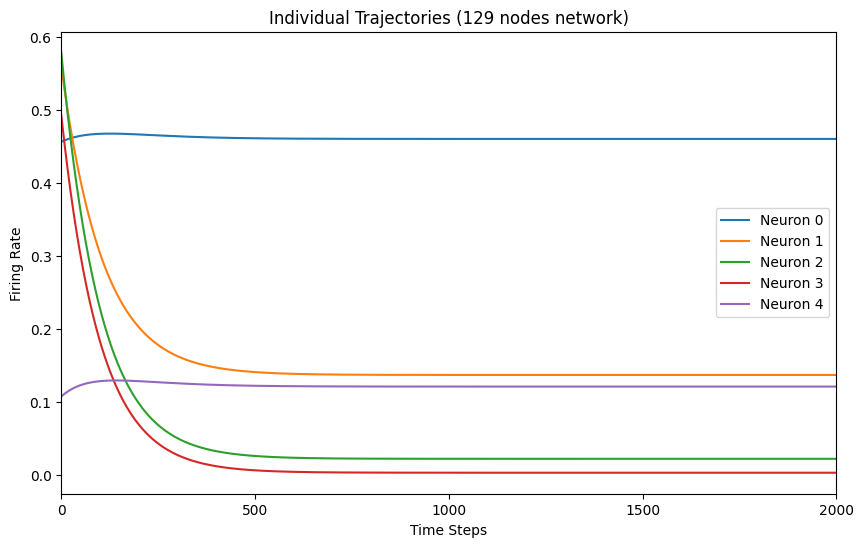

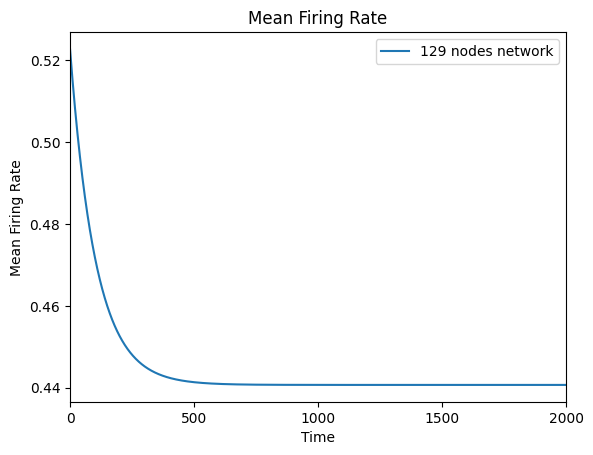

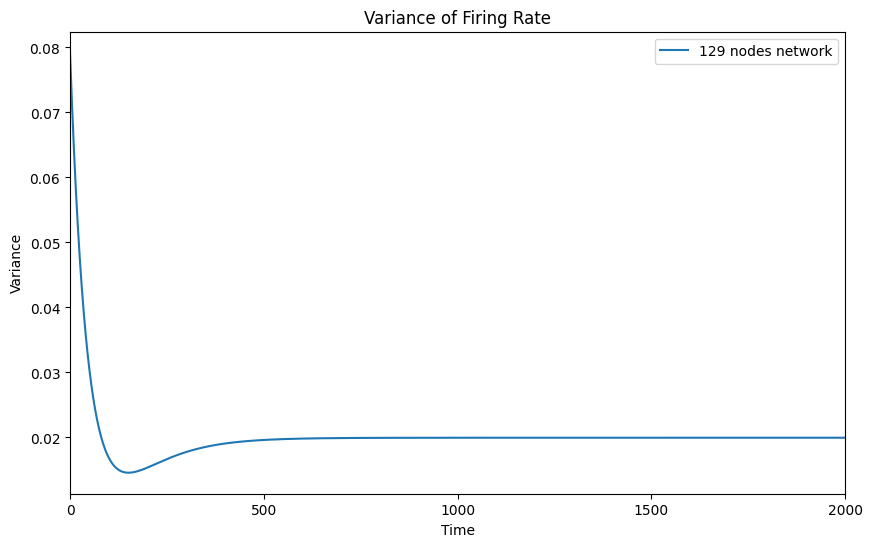

In [ ]:
folder_paths = [folder_path_83, folder_path_129]

for folder_path in folder_paths:
    process_dataset(folder_path)

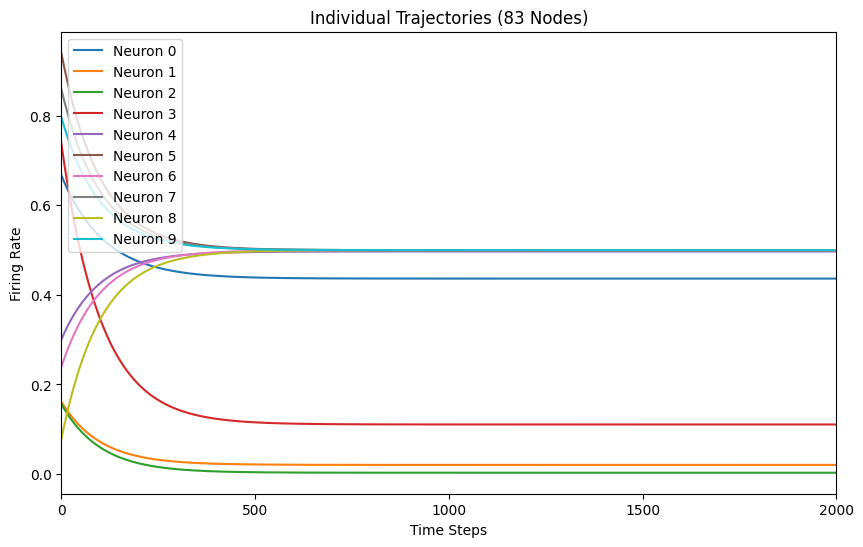

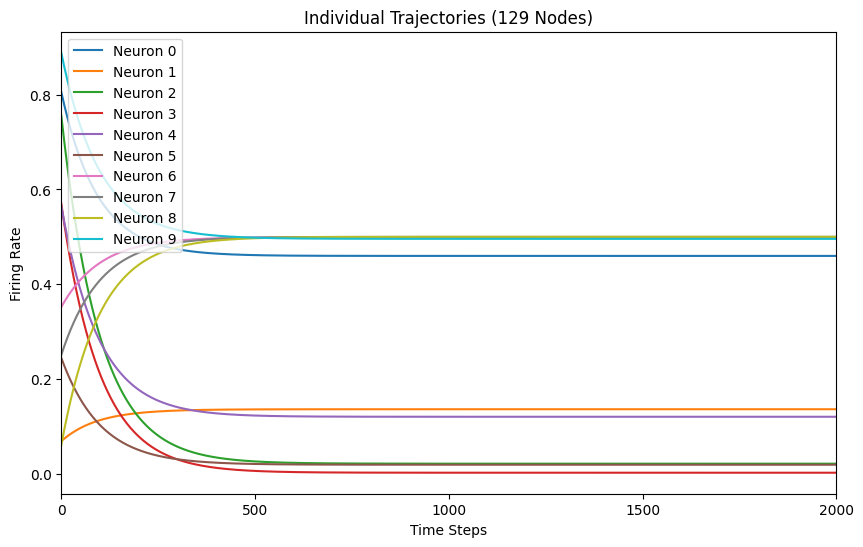

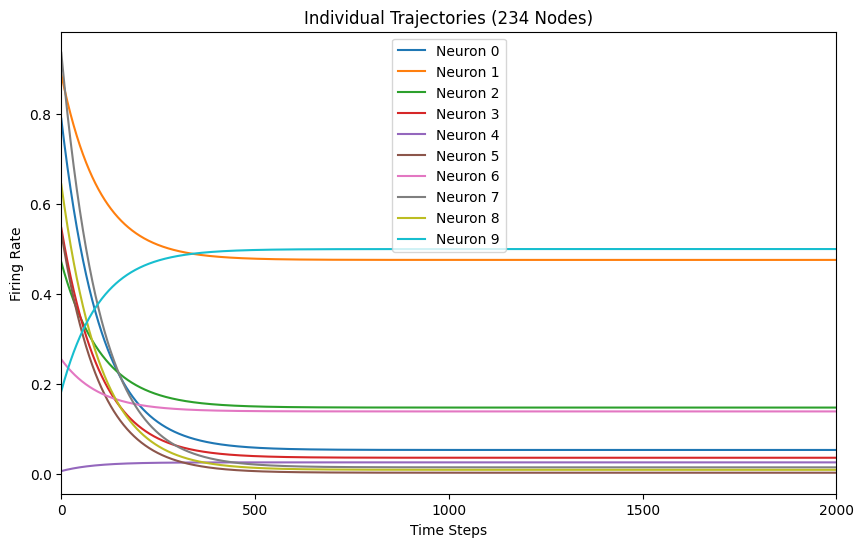

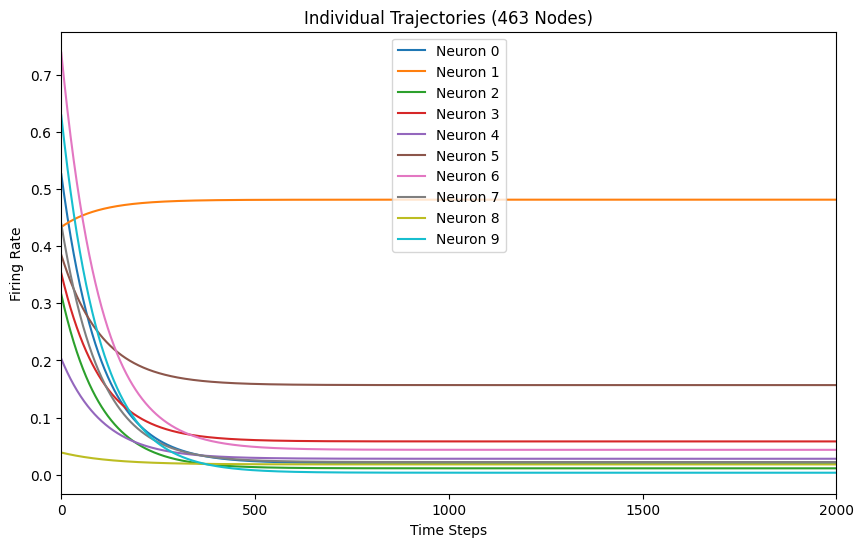

NotADirectoryError: [Errno 20] Not a directory: '/Users/budapest/Desktop/ESN_project/code/Averaged_1015.graphml'

In [12]:
# plotting individual trajectories and comparative means and variances
folder_paths = [folder_path_83, folder_path_129, folder_path_234, folder_path_463, averaged_1015]
is_averaged = [False, False, False, False, False, True]  # Mark averaged connectome
network_names = ['83 Nodes', '129 Nodes', '234 Nodes', '463 Nodes', '1015 Nodes', 'Averaged 1015']

rates_data_networks = []
mean_firing_rates = []
variance_firing_rates = []

for folder_path, avg in zip(folder_paths, is_averaged):
    rates, mean_rate, variance_rate, N = process_dataset(folder_path, avg)
    rates_data_networks.append(rates)
    mean_firing_rates.append(mean_rate)
    variance_firing_rates.append(variance_rate)

    # Plot individual trajectories for each network
    plt.figure(figsize=(10, 6))
    for i in range(min(10, rates.shape[1])):  
        plt.plot(rates[:, i], label=f'Neuron {i}')
    plt.title(f'Individual Trajectories ({network_names[folder_paths.index(folder_path)]})')
    plt.xlabel('Time Steps')
    plt.ylabel('Firing Rate')
    plt.legend()
    plt.xlim(0, 2000)  
    plt.xticks(np.arange(0, 2001, 500))
    plt.show()

# means and variances for all networks
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
for i, (mean_rate, variance_rate) in enumerate(zip(mean_firing_rates, variance_firing_rates)):
    axs[0].plot(mean_rate, label=network_names[i])
    axs[1].plot(variance_rate, label=network_names[i])

axs[0].set_title('Mean Firing Rates')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Mean Firing Rate')
axs[0].set_xlim(0, 2000)
axs[0].set_xticks(np.arange(0, 2001, 500))
axs[0].legend()

axs[1].set_title('Variance of Firing Rates')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Variance')
axs[1].set_xlim(0, 2000)
axs[1].set_xticks(np.arange(0, 2001, 500))
axs[1].legend()

plt.tight_layout()
plt.show()